<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  5.83MB/s    in 31s     
2026-09-28 07:51:35 (4.96 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [2]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 152.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 154.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 143.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 140.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [31]:
!pip install seaborn

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [3]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [4]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [5]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [6]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [7]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [9]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


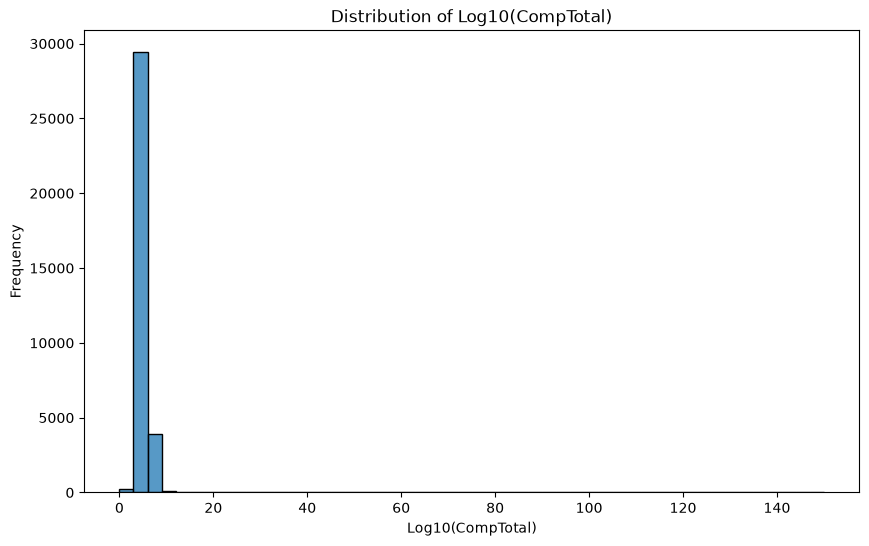

In [32]:
import seaborn as sns
import numpy as np

QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
AND CompTotal > 0
"""

df_comp = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(10, 6))
sns.histplot(np.log10(df_comp['CompTotal']), bins=50)

plt.title('Distribution of Log10(CompTotal)')
plt.xlabel('Log10(CompTotal)')
plt.ylabel('Frequency')
plt.show()

**Box Plots**

Plot a box plot of Age.


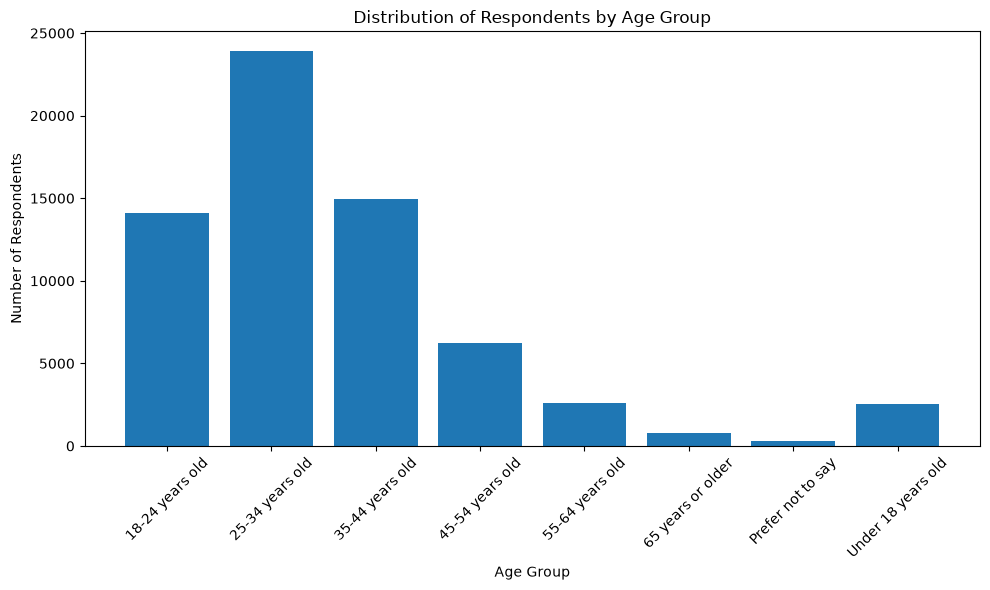

In [37]:
QUERY = """
SELECT Age, COUNT(*) AS Count
FROM main
WHERE Age IS NOT NULL
GROUP BY Age
ORDER BY Age
"""

df_age = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(10, 6))

plt.bar(df_age['Age'], df_age['Count'])

plt.title('Distribution of Respondents by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Respondents')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


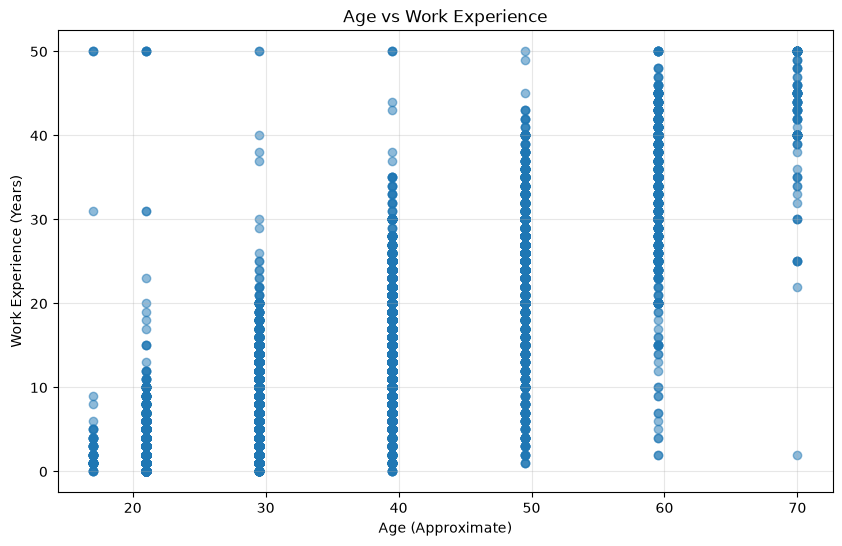

In [38]:
# Extract data using SQL
QUERY = """
SELECT Age, WorkExp
FROM main
WHERE Age IS NOT NULL
AND WorkExp IS NOT NULL
"""

df_age_work = pd.read_sql_query(QUERY, conn)

# Map age brackets to approximate numeric values
age_map = {
'Under 18 years old': 17,
'18-24 years old': 21,
'25-34 years old': 29.5,
'35-44 years old': 39.5,
'45-54 years old': 49.5,
'55-64 years old': 59.5,
'65 years or older': 70
}

df_age_work['AgeNumeric'] = df_age_work['Age'].map(age_map)

# Remove any rows that failed mapping
df_age_work = df_age_work.dropna(subset=['AgeNumeric'])

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
df_age_work['AgeNumeric'],
df_age_work['WorkExp'],
alpha=0.5
)

plt.title('Age vs Work Experience')
plt.xlabel('Age (Approximate)')
plt.ylabel('Work Experience (Years)')

plt.grid(True, alpha=0.3)
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


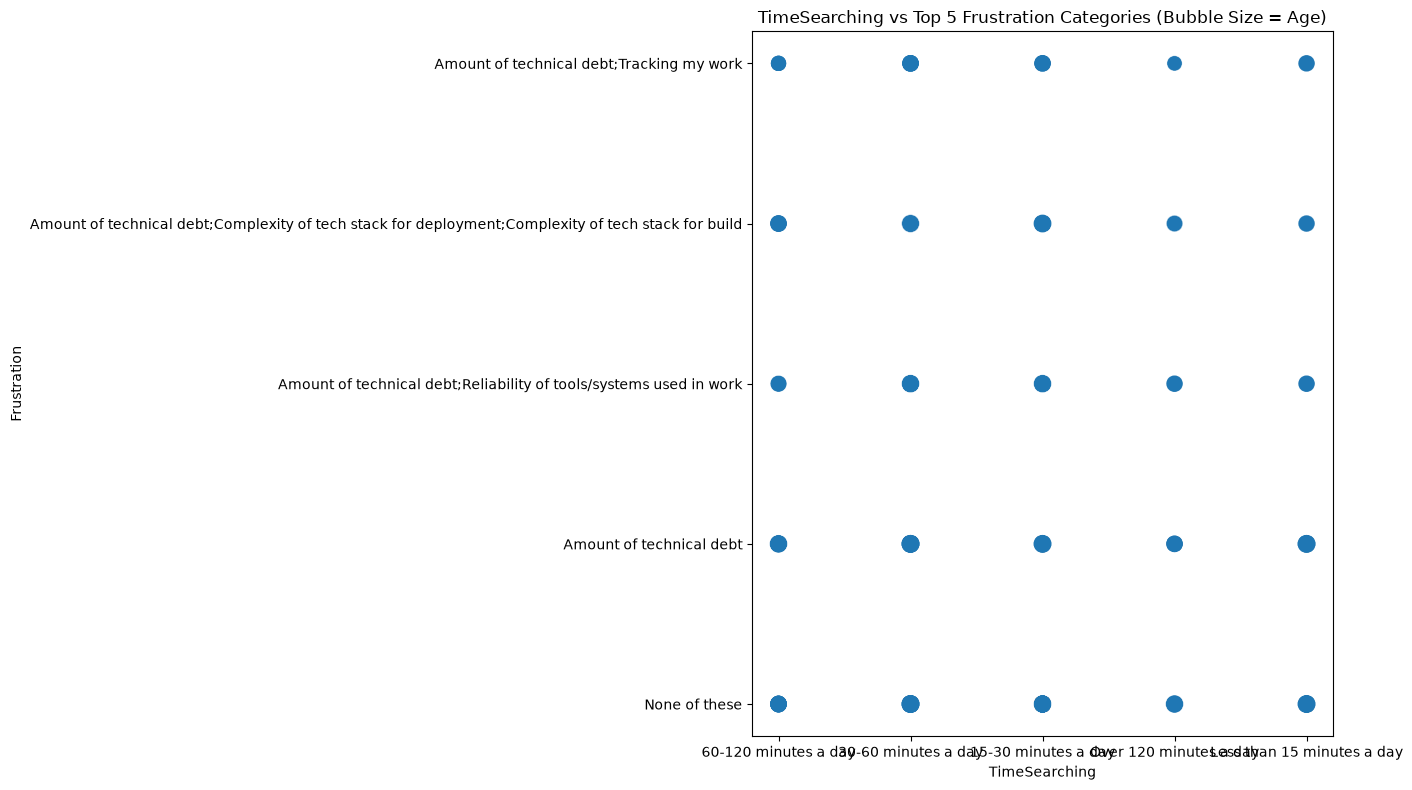

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract data
QUERY = """
SELECT TimeSearching, Frustration, Age
FROM main
WHERE TimeSearching IS NOT NULL
AND Frustration IS NOT NULL
AND Age IS NOT NULL
"""

df_bubble = pd.read_sql_query(QUERY, conn)

# Get top 5 frustration categories
top5_frustration = df_bubble['Frustration'].value_counts().head(5).index

# Keep only top 5
df_bubble = df_bubble[df_bubble['Frustration'].isin(top5_frustration)]

# Convert Age categories to numeric values
age_map = {
'Under 18 years old': 17,
'18-24 years old': 21,
'25-34 years old': 29.5,
'35-44 years old': 39.5,
'45-54 years old': 49.5,
'55-64 years old': 59.5,
'65 years or older': 70
}

df_bubble['AgeNumeric'] = df_bubble['Age'].map(age_map)

# Convert Frustration categories to numeric positions
frustration_order = top5_frustration.tolist()
frustration_mapping = {
category: i for i, category in enumerate(frustration_order)
}

df_bubble['FrustrationNum'] = df_bubble['Frustration'].map(frustration_mapping)

# Plot bubble chart
plt.figure(figsize=(14, 8))

plt.scatter(
df_bubble['TimeSearching'],
df_bubble['FrustrationNum'],
s=df_bubble['AgeNumeric'] * 2,
alpha=0.5
)

plt.yticks(
range(len(frustration_order)),
frustration_order
)

plt.xlabel('TimeSearching')
plt.ylabel('Frustration')
plt.title('TimeSearching vs Top 5 Frustration Categories (Bubble Size = Age)')

plt.tight_layout()
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


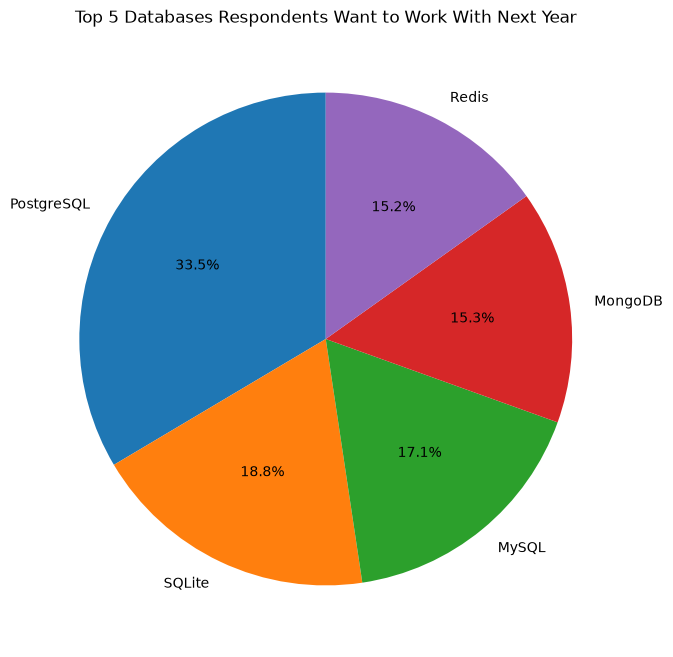

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Extract data using SQL
QUERY = """
SELECT DatabaseWantToWorkWith
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
"""

df_db = pd.read_sql_query(QUERY, conn)

# Split database names and count occurrences
db_counter = Counter()

for databases in df_db['DatabaseWantToWorkWith']:
    db_counter.update(databases.split(';'))

# Create DataFrame of counts
db_counts = pd.DataFrame(
    db_counter.items(),
    columns=['Database', 'Count']
)

# Top 5 databases
top5 = db_counts.sort_values(
    by='Count',
    ascending=False
).head(5)

# Plot pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top5['Count'],
    labels=top5['Database'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Top 5 Databases Respondents Want to Work With Next Year')

plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


TimeSearching
30-60 minutes a day           4901
15-30 minutes a day           3332
60-120 minutes a day          2345
Less than 15 minutes a day    1047
Over 120 minutes a day         978
Name: count, dtype: int64
TimeAnswering
15-30 minutes a day           4226
30-60 minutes a day           3833
Less than 15 minutes a day    2510
60-120 minutes a day          1534
Over 120 minutes a day         458
Name: count, dtype: int64

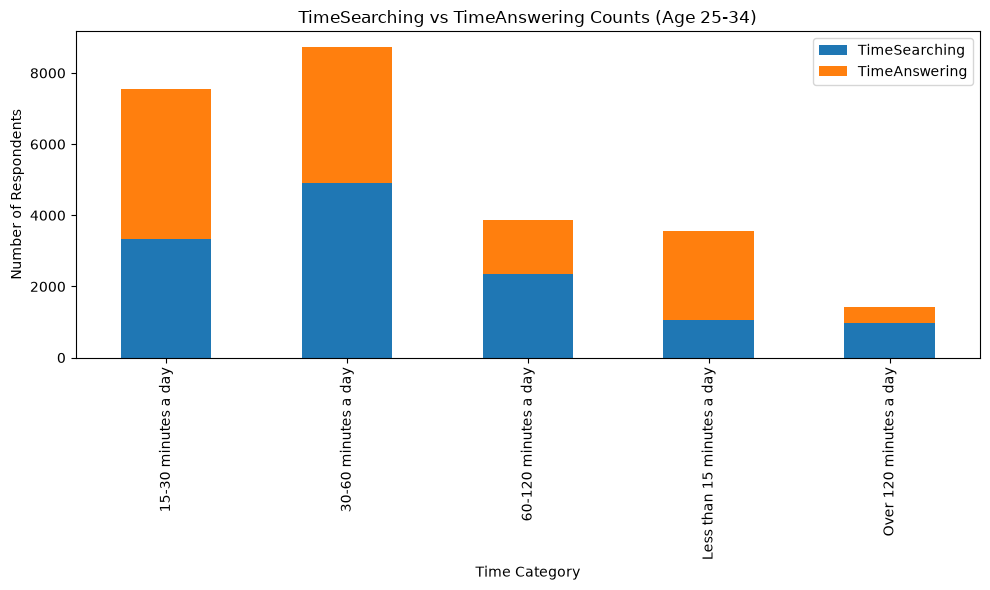

In [50]:
QUERY = """
SELECT TimeSearching, TimeAnswering
FROM main
WHERE Age = '25-34 years old'
"""

df = pd.read_sql_query(QUERY, conn)

search_counts = df['TimeSearching'].value_counts()
answer_counts = df['TimeAnswering'].value_counts()

print(search_counts)
print(answer_counts)

import pandas as pd
import matplotlib.pyplot as plt

# Combine counts into one dataframe
counts_df = pd.DataFrame({
    'TimeSearching': search_counts,
    'TimeAnswering': answer_counts
}).fillna(0)

# Plot stacked bar chart
counts_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('TimeSearching vs TimeAnswering Counts (Age 25-34)')
plt.xlabel('Time Category')
plt.ylabel('Number of Respondents')
plt.legend()
plt.tight_layout()

plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


               Age  CompTotal
0  45-54 years old   130000.0
1  55-64 years old   135000.0

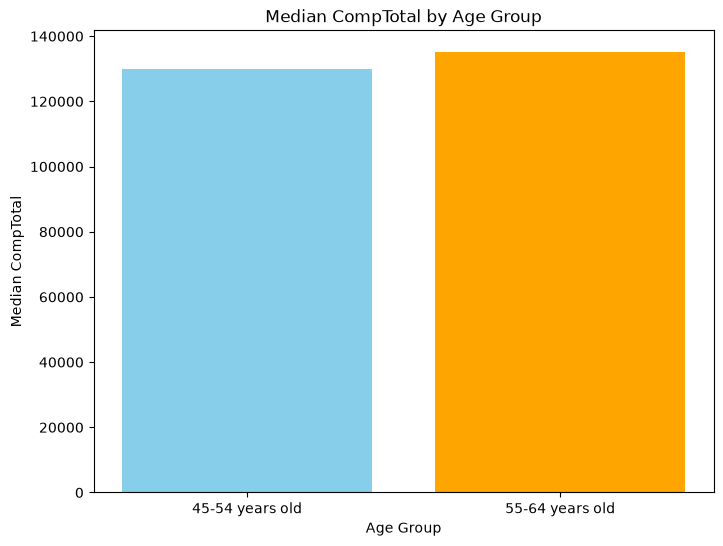

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract data
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IN ('45-54 years old', '55-64 years old')
AND CompTotal IS NOT NULL
"""

df = pd.read_sql_query(QUERY, conn)

# Calculate median CompTotal for each age group
median_comp = (
df.groupby('Age')['CompTotal']
.median()
.reset_index()
)

print(median_comp)

plt.figure(figsize=(8, 6))

plt.bar(
median_comp['Age'],
median_comp['CompTotal'],
color=['skyblue', 'orange']
)

plt.title('Median CompTotal by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median CompTotal')

plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


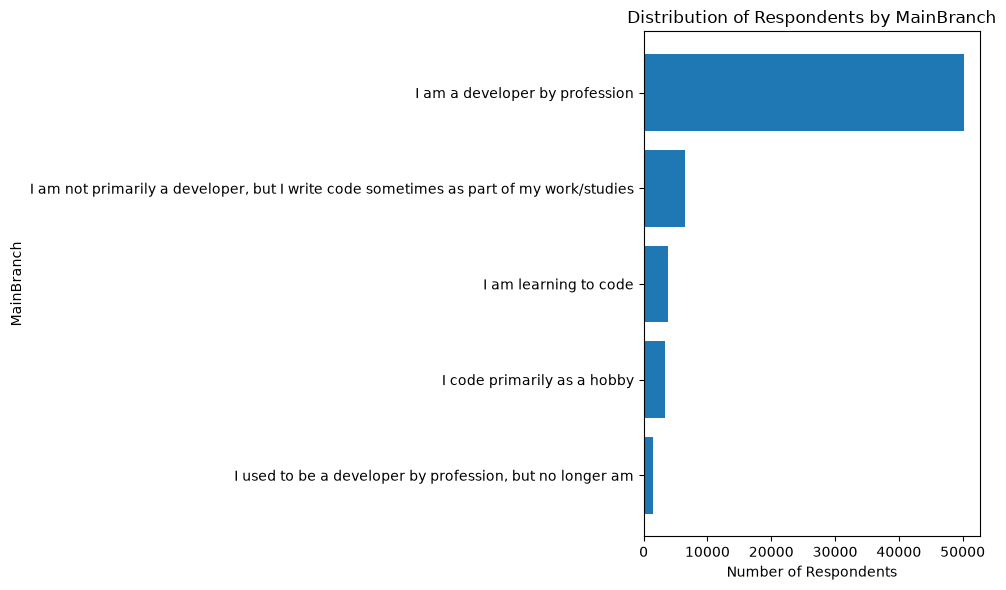

In [52]:
QUERY = """
SELECT MainBranch, COUNT(MainBranch) AS Count
FROM main
WHERE MainBranch IS NOT NULL
GROUP BY MainBranch
ORDER BY Count DESC
"""

df_mainbranch = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(10, 6))

plt.barh(
    df_mainbranch['MainBranch'],
    df_mainbranch['Count']
)

plt.title('Distribution of Respondents by MainBranch')
plt.xlabel('Number of Respondents')
plt.ylabel('MainBranch')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [53]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
